<a href="https://colab.research.google.com/github/revanth2605/Digital-image-processing/blob/main/digital_image_processing_exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load the image "lena_256.jpg" and be ready for further instructions on image processing tasks.

## Load Image

### Subtask:
Load the `lena_256.jpg` image into a suitable image processing library (e.g., OpenCV or PIL).


**Reasoning**:
First, I'll import the necessary library for image processing, Pillow (PIL), and then proceed to load the specified image from the file system.



In [ ]:
from PIL import Image

# Load the image
img = Image.open('lena_256.jpg')

# Display the image
img.show()
print("Image loaded successfully and displayed.")

Image loaded successfully and displayed.


### Subtask:
Save the loaded image into different formats (e.g., PNG, JPEG, BMP).

**Reasoning**:
I will use the `save()` method of the Pillow (PIL) Image object to write the image to different file formats. Pillow automatically infers the format from the file extension.

In [ ]:
from PIL import Image

# Ensure 'img' is loaded. If the previous cell was not run, this would fail.
# For demonstration, let's assume 'img' from cell 'ba220078' is available.
# If not, you might want to uncomment the line below:
# img = Image.open('lena_256.jpg')

# Save as PNG
img.save('lena_256.png')
print("Image saved as lena_256.png")

# Save as JPEG (note: JPEG does not support transparency, and quality can be adjusted)
# For grayscale images, convert to 'RGB' first if saving as JPEG might cause issues
# or if the original image has an alpha channel that needs to be handled.
if img.mode == 'RGBA':
    img.convert('RGB').save('lena_256.jpg')
else:
    img.save('lena_256.jpg')
print("Image saved as lena_256.jpg")

# Save as BMP
img.save('lena_256.bmp')
print("Image saved as lena_256.bmp")


Image saved as lena_256.png
Image saved as lena_256.jpg
Image saved as lena_256.bmp


### Displaying Color Planes within Colab

To explicitly display the image planes directly within the Colab output cells, we can use `IPython.display` with the Pillow image objects. This provides a visible output in the notebook.

RED Plane:


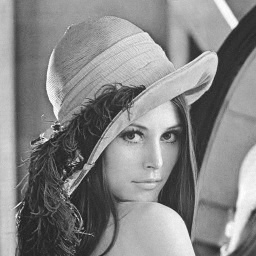

GREEN Plane:


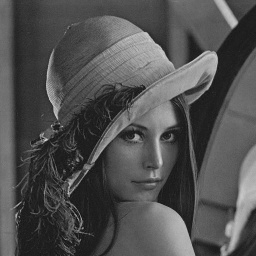

BLUE Plane:


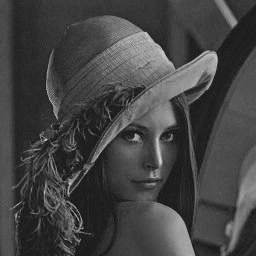

In [ ]:
from IPython.display import display
from PIL import Image

# Assuming r_plane, g_plane, b_plane are already extracted from the 'img' object
# If not, you might need to run the previous extraction cell or load the image again:
# img = Image.open('lena_256.jpg')
# r_plane, g_plane, b_plane = img.split()

print("RED Plane:")
display(r_plane)

print("GREEN Plane:")
display(g_plane)

print("BLUE Plane:")
display(b_plane)


### Subtask:
Convert the color image to grayscale and binary images, and display them together.

**Reasoning**:
I will first convert the `img` (color image) to grayscale using the `convert('L')` method of Pillow. Then, I will convert the grayscale image to a binary image by applying a threshold. Finally, I'll use `matplotlib.pyplot` to display the original color image, the grayscale image, and the binary image side-by-side in a single figure.

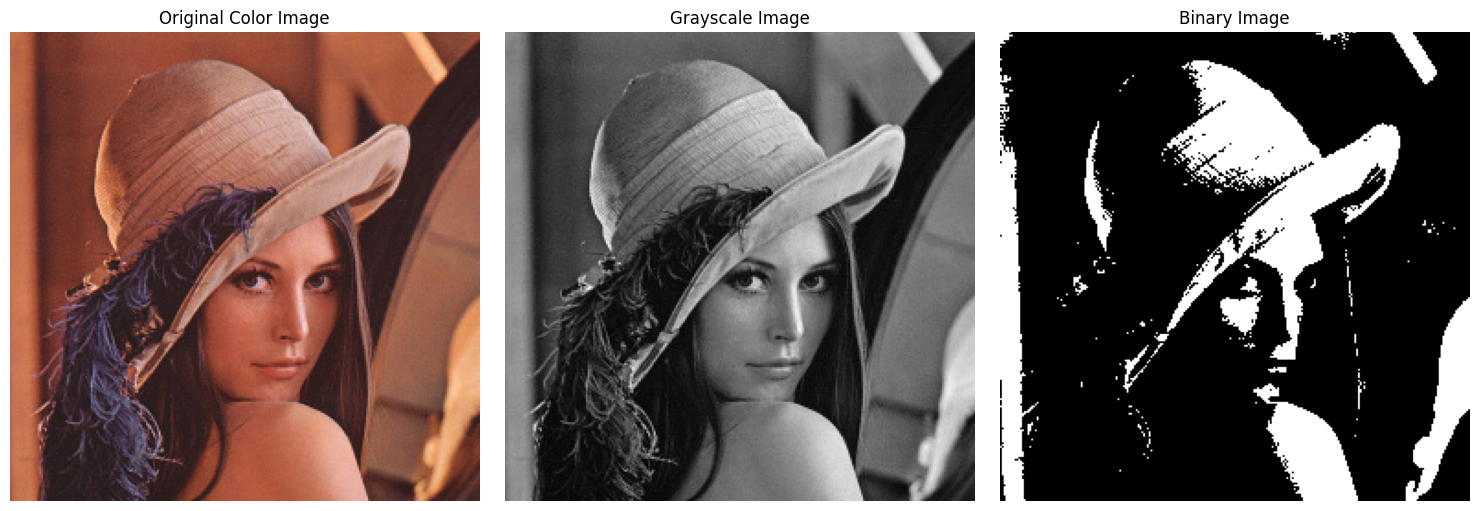

Color image converted to grayscale and binary, and all three are displayed.


In [ ]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Assuming 'img' is the loaded color image from a previous step.
# If not, uncomment the line below:
# img = Image.open('lena_256.jpg')

# Convert to Grayscale
grayscale_img = img.convert('L')

# Convert to Binary Image (using a simple threshold)
# First, convert to numpy array for easier thresholding
import numpy as np
grayscale_np = np.array(grayscale_img)

# Choose a threshold value (e.g., 128 for 0-255 range)
threshold = 128
binary_np = (grayscale_np > threshold) * 255
binary_img = Image.fromarray(binary_np.astype(np.uint8))

# Display all three images in one figure
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st subplot
plt.imshow(img)
plt.title('Original Color Image')
plt.axis('off') # Hide axes

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd subplot
plt.imshow(grayscale_img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd subplot
plt.imshow(binary_img, cmap='gray')
plt.title('Binary Image')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Color image converted to grayscale and binary, and all three are displayed.")

### Subtask:
Resize the image by one half and one quarter.

**Reasoning**:
I will use the `resize()` method from the Pillow (PIL) library to scale down the `img` object. First, I'll calculate the new dimensions for half size, then for quarter size, and finally display all three images (original, half, and quarter) using `matplotlib.pyplot` for side-by-side comparison.

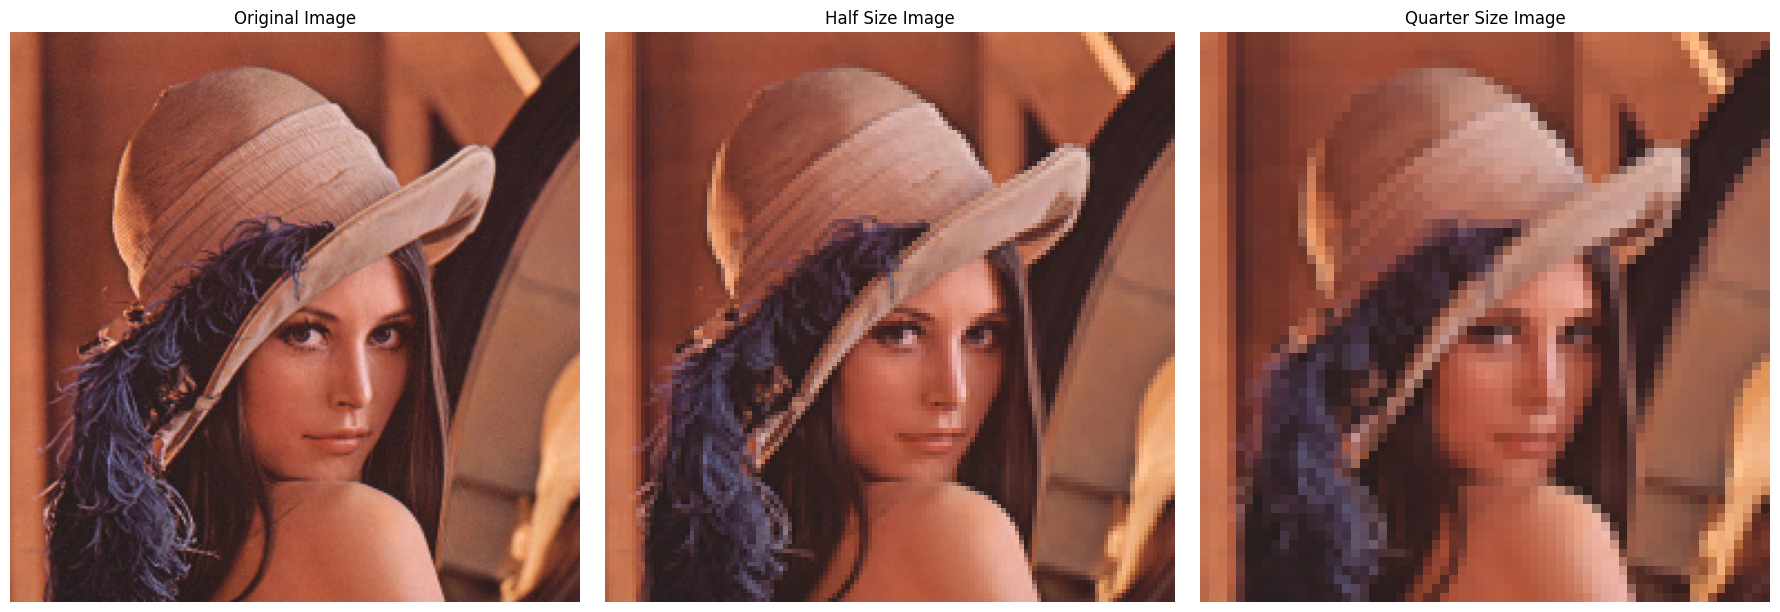

Image resized to half and quarter sizes, and all three are displayed.


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Assuming 'img' is the loaded color image from a previous step.
# If not, uncomment the line below:
# img = Image.open('lena_256.jpg')

# Get original dimensions
original_width, original_height = img.size

# Resize to one half
half_size_img = img.resize((original_width // 2, original_height // 2))

# Resize to one quarter
quarter_size_img = img.resize((original_width // 4, original_height // 4))

# Display original and resized images
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st subplot
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd subplot
plt.imshow(half_size_img)
plt.title('Half Size Image')
plt.axis('off')

plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd subplot
plt.imshow(quarter_size_img)
plt.title('Quarter Size Image')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Image resized to half and quarter sizes, and all three are displayed.")


### Subtask:
Apply blurring filters (Gaussian blur and Box blur) to the image.

**Reasoning**:
I will use the `ImageFilter` module from the Pillow (PIL) library to apply Gaussian Blur and Box Blur to the `img` object. I will then use `matplotlib.pyplot` to display the original image, the Gaussian blurred image, and the Box blurred image side-by-side for comparison.

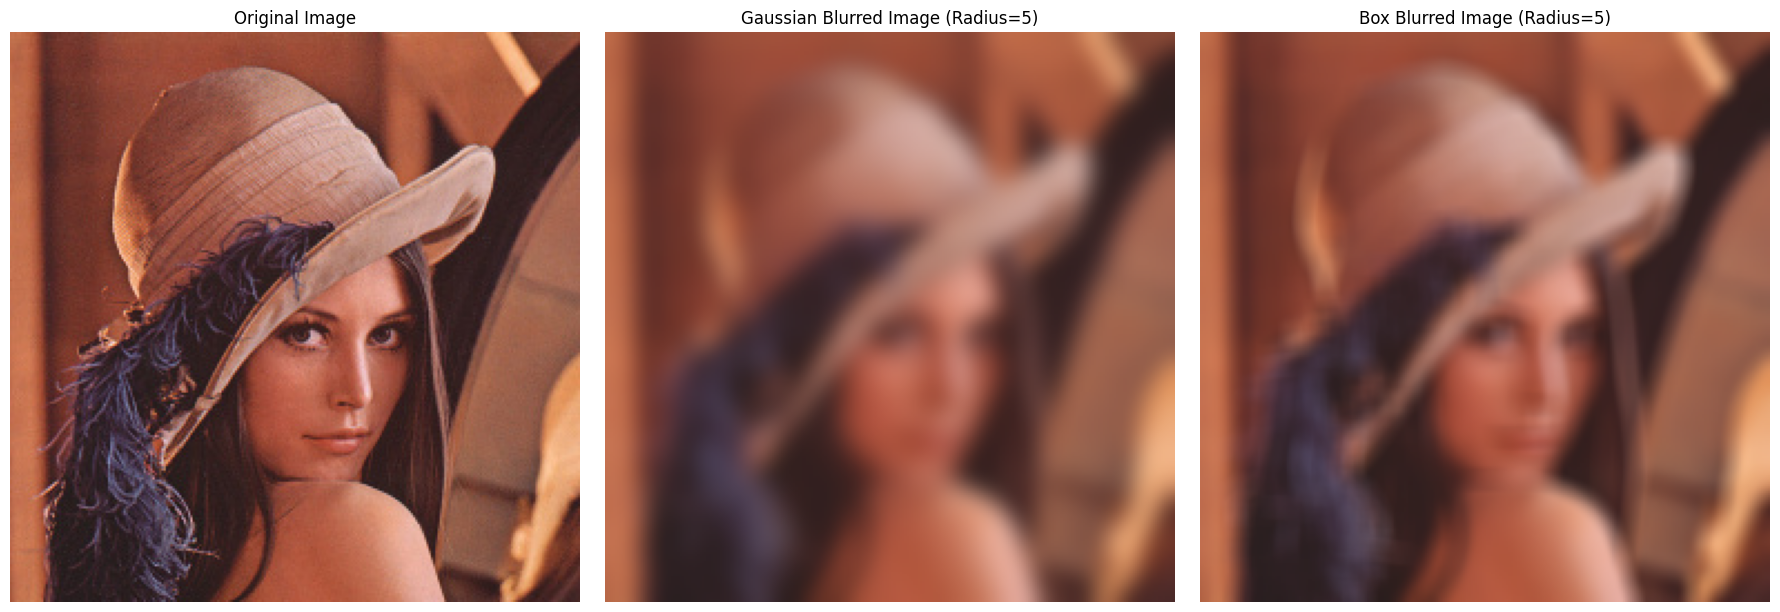

Original, Gaussian blurred, and Box blurred images are displayed.


In [ ]:
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

# Assuming 'img' is the loaded color image from a previous step.
# If not, uncomment the line below:
# img = Image.open('lena_256.jpg')

# Apply Gaussian Blur
# The radius parameter controls the strength of the blur.
gaussian_blurred_img = img.filter(ImageFilter.GaussianBlur(radius=5))

# Apply Box Blur
# The radius parameter controls the strength of the blur.
box_blurred_img = img.filter(ImageFilter.BoxBlur(radius=5))

# Display original and blurred images
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st subplot
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd subplot
plt.imshow(gaussian_blurred_img)
plt.title('Gaussian Blurred Image (Radius=5)')
plt.axis('off')

plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd subplot
plt.imshow(box_blurred_img)
plt.title('Box Blurred Image (Radius=5)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Original, Gaussian blurred, and Box blurred images are displayed.")


### Subtask:
Rotate the image by -45°, -60°, and 270°.

**Reasoning**:
I will use the `rotate()` method from the Pillow (PIL) library to apply the specified rotations to the `img` object. The `expand=True` argument will be used to ensure the entire rotated image is visible. Finally, I'll use `matplotlib.pyplot` to display the original image and all three rotated images side-by-side for comparison.

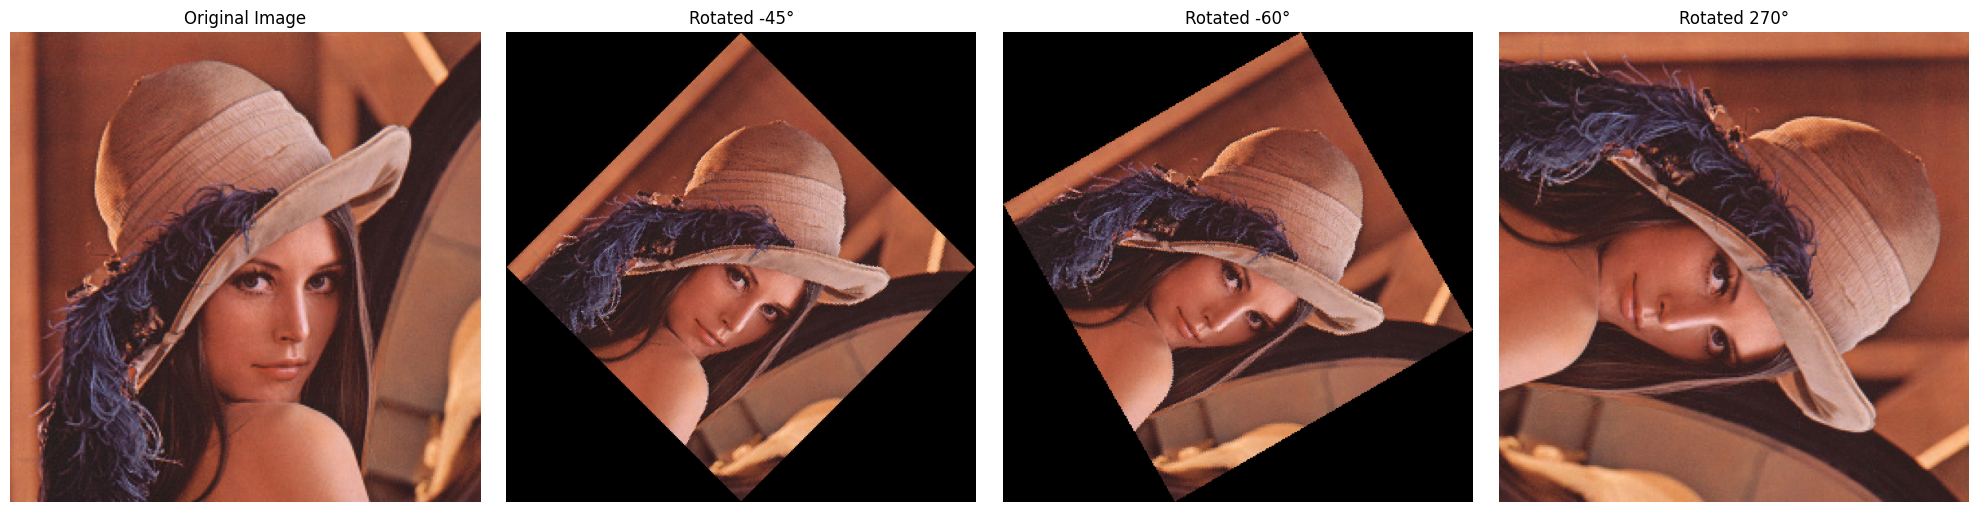

Image rotated by -45°, -60°, and 270°, and all are displayed.


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Assuming 'img' is the loaded color image from a previous step.
# If not, uncomment the line below:
# img = Image.open('lena_256.jpg')

# Rotate by -45 degrees
rotated_neg45_img = img.rotate(-45, expand=True)

# Rotate by -60 degrees
rotated_neg60_img = img.rotate(-60, expand=True)

# Rotate by 270 degrees
rotated_270_img = img.rotate(270, expand=True)

# Display original and rotated images
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1) # 1 row, 4 columns, 1st subplot
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2) # 1 row, 4 columns, 2nd subplot
plt.imshow(rotated_neg45_img)
plt.title('Rotated -45°')
plt.axis('off')

plt.subplot(1, 4, 3) # 1 row, 4 columns, 3rd subplot
plt.imshow(rotated_neg60_img)
plt.title('Rotated -60°')
plt.axis('off')

plt.subplot(1, 4, 4) # 1 row, 4 columns, 4th subplot
plt.imshow(rotated_270_img)
plt.title('Rotated 270°')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Image rotated by -45°, -60°, and 270°, and all are displayed.")
